## 1. Importing the libraries

In [89]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from sklearn.linear_model import LinearRegression

## 2. Configuration to use in the file 

In [90]:
# Dataset configuration
DATASET_PATH = "./car_braking_data.csv"
TARGET_COLUMN = "BrakingDistance"

# Train test spit configuration
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Model configuration
POLYNOMIAL_DEGREE = 3
LINEAR_REGRESSION_PARAMS = {}

# Visualization configuration
FIGURE_SIZE = (10, 10)
ALPHA = 0.6

## 3. Helper Functions

In [91]:
def evaluate_model(y_test, y_pred):
    print("R2 Score: ", r2_score(y_test, y_pred))
    print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
    print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
    print("Root mean squared error: ", root_mean_squared_error(y_test, y_pred))

In [92]:
def before_vs_after_plot(y_test, y_pred):
    plt.figure(figsize=FIGURE_SIZE)

    plt.plot(y_test.values[:50], label="Actual Values (Before)")
    plt.plot(y_pred[:50], label="Predicted Values (After)")

    plt.title("Before vs After Prediction (Actual vs Predicted Values)")
    plt.xlabel("Sample Index")
    plt.ylabel("Y (Target Value)")
    
    plt.legend()
    plt.grid(True)
    plt.show()

In [93]:
def display_prediction_examples(model, prediction_examples, poly_transformer, scaler):

    print("=" * 20)
    print("Prediction Examples")
    print("=" * 20)

    for example_name, example_data in prediction_examples.items():

        transformed = poly_transformer.transform(example_data)
        transformed = scaler.transform(transformed)

        prediction = model.predict(transformed)[0]

        print(f"\nScenario : {example_name}")
        print("-" * 20)
        print(example_data)

        print(f"\nPrediction Breaking distance: {prediction:.2f}")

## 4. Loading the Dataset

In [94]:
df = pd.read_csv(DATASET_PATH)

## 5. Understanding the dataset / Dataset overview

In [95]:
df.shape

(1801, 2)

In [96]:
df.columns

Index(['Speed', 'BrakingDistance'], dtype='str')

In [97]:
df.head()

,Speed,BrakingDistance
0,0.000000,7.450712
1,0.066667,-2.073742
2,0.133333,9.716217
3,0.200000,22.847448
4,0.266667,-3.508745


In [98]:
df.isnull().sum()

Speed              0
BrakingDistance    0
dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1801 entries, 0 to 1800
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Speed            1801 non-null   float64
 1   BrakingDistance  1801 non-null   float64
dtypes: float64(2)
memory usage: 28.3 KB


In [101]:
df.describe()

,Speed,BrakingDistance
count,1801.000000,1801.000000
mean,60.000000,240.802278
std,34.669882,215.813778
min,0.000000,-38.079288
25%,30.000000,44.963113
50%,60.000000,183.885261
75%,90.000000,401.496931
max,120.000000,748.517860


## 6. Defining the feature list

In [102]:
NUMERICAL_COLUMNS = df.select_dtypes(include='number').columns.tolist()

## 7. Outlier Analysis

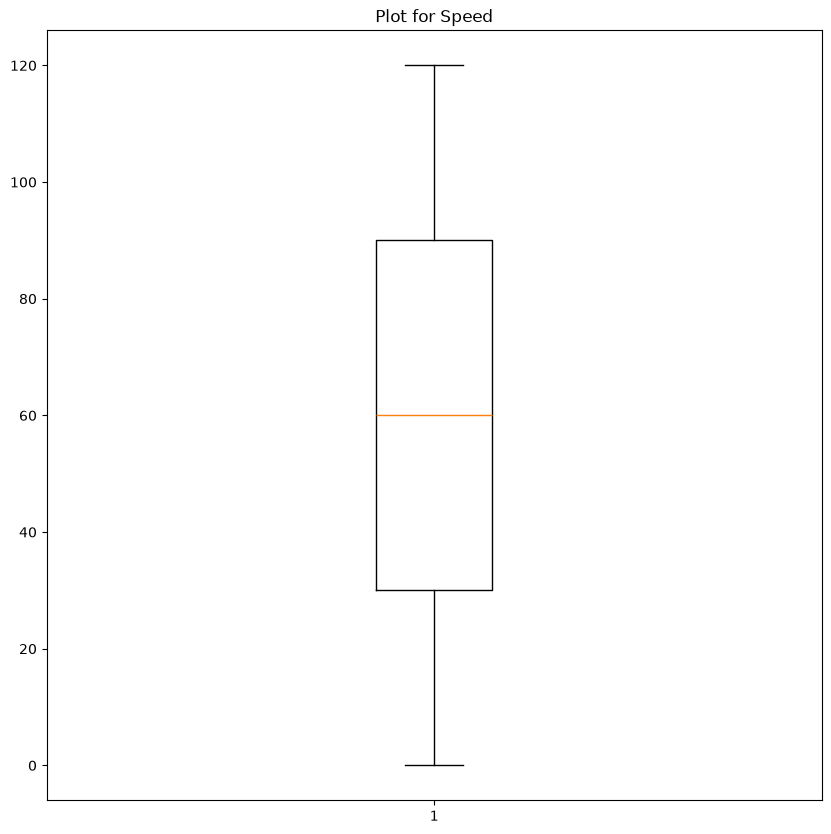

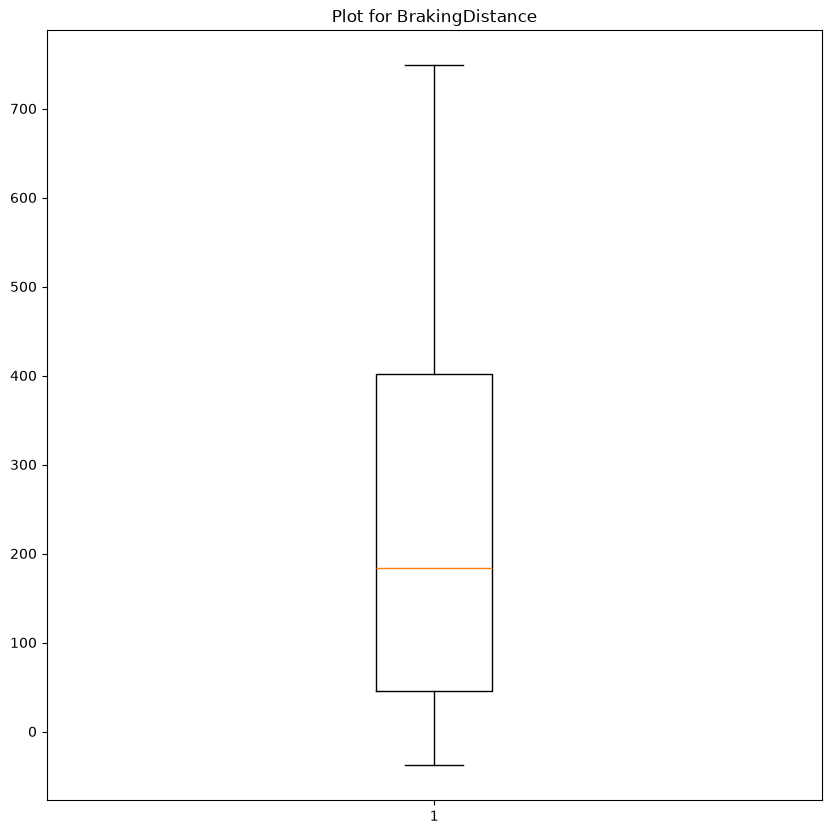

In [103]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=FIGURE_SIZE)

    plt.boxplot(x=df[col])

    plt.title(f"Plot for {col}")
    plt.show()

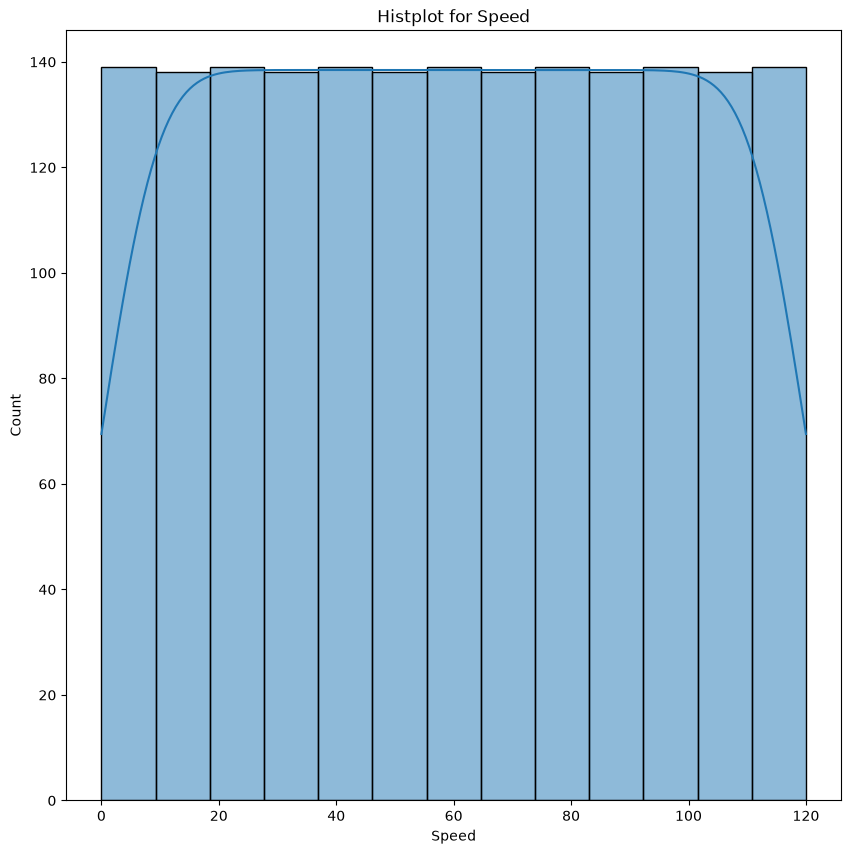

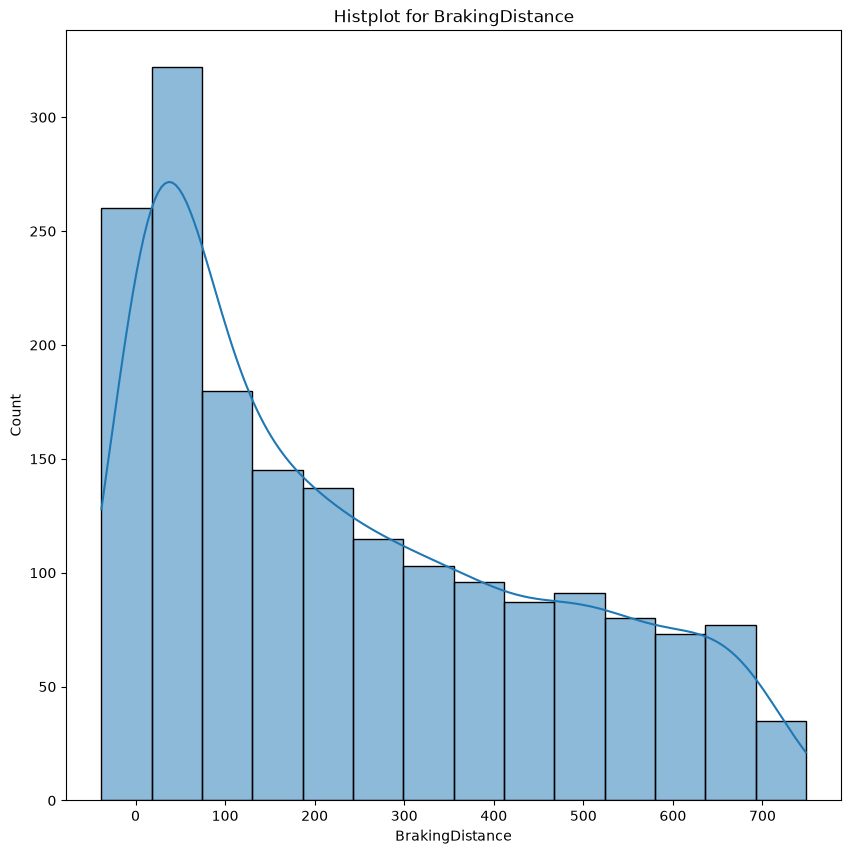

In [104]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=FIGURE_SIZE)

    sns.histplot(df[col], kde=True)
    plt.title(f"Histplot for {col}")

    plt.show()

There are no visual prominent outliers in the plots and the distributions are fairly balanced so based on the observations there are no possible outliers observed until now.

## 8. Correlation Analysis

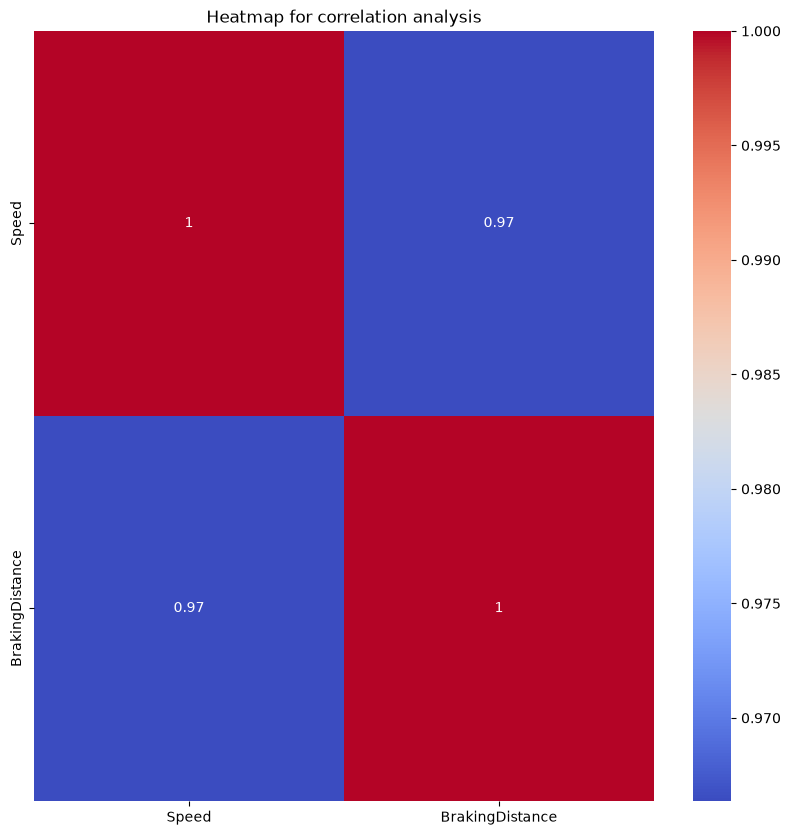

In [105]:
corr = df[NUMERICAL_COLUMNS].corr()

plt.figure(figsize=FIGURE_SIZE)
sns.heatmap(
    corr, 
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap for correlation analysis")
plt.show()

As the dataset is structured based on only 2 columns there are obvious relations present in the dataset

#### Preprocessing decisions

✓ Will apply scaling

Reason:
the model being used is a gradient based regression algorithm so scaling is preferred to make the predictions better

## 9. Preparing the data for model training

In [106]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1440, 1)
(361, 1)
(1440,)
(361,)


## 10. Creating the pipeline for split data

In [108]:
poly_transformer = PolynomialFeatures(
    degree=POLYNOMIAL_DEGREE,
    include_bias=False
)

## 11. Fitting the pipeline on the split data

In [109]:
X_train_poly = poly_transformer.fit_transform(X_train)

In [110]:
X_test_poly = poly_transformer.transform(X_test)

## 12. Scaling the the featured data

In [111]:
scaler = StandardScaler()

In [112]:
X_train_poly = scaler.fit_transform(X_train_poly)

In [113]:
X_test_poly = scaler.transform(X_test_poly)

## 13. Fitting the processed data to the model

In [114]:
linear_regression_model = LinearRegression(**LINEAR_REGRESSION_PARAMS)

In [115]:
linear_regression_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 1.58,211.62, 0.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,238.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[64.76,11.18, 1.29]"


## 14. Evaluating the model metrics

In [116]:
y_pred = linear_regression_model.predict(X_test_poly)

In [117]:
evaluate_model(y_test, y_pred)

R2 Score:  0.9954314159912604
Mean Absolute Error:  11.974283081993836
Mean Squared Error:  225.34955409258612
Root mean squared error:  15.011647281114293


## 15. Visualization of model predictions

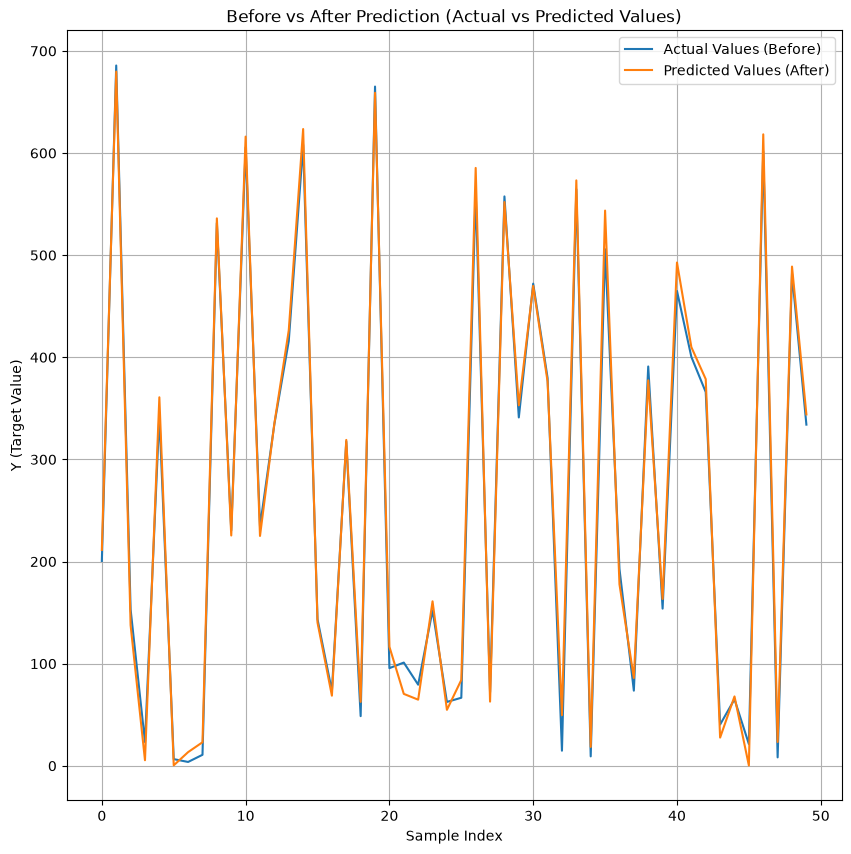

In [118]:
before_vs_after_plot(y_test, y_pred)

## 16. Prediction examples

In [119]:
prediction_examples = {
    "typical_speed": pd.DataFrame({
        'Speed': [30.0]
        }),
    "high_speed": pd.DataFrame({
    'Speed': [
        150.0,   # Speed higher than the dataset maximum (120)
    ]
})
}

In [120]:
print(poly_transformer.get_feature_names_out(X_train.columns))

['Speed' 'Speed^2' 'Speed^3']


In [121]:
display_prediction_examples(linear_regression_model, prediction_examples, poly_transformer, scaler)

Prediction Examples

Scenario : typical_speed
--------------------
   Speed
0   30.0

Prediction Breaking distance: 45.26

Scenario : high_speed
--------------------
   Speed
0  150.0

Prediction Breaking distance: 1126.87
